In [2]:
import pandas as pd
covid_df = pd.read_csv('../data/new datasset + classifications/covid19_patient_symptoms_diagnosis.csv')

covid_df.describe()
covid_df.info()
covid_df.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   patient_id            5000 non-null   int64  
 1   age                   5000 non-null   int64  
 2   gender                5000 non-null   str    
 3   fever                 5000 non-null   int64  
 4   dry_cough             5000 non-null   int64  
 5   sore_throat           5000 non-null   int64  
 6   fatigue               5000 non-null   int64  
 7   headache              5000 non-null   int64  
 8   shortness_of_breath   5000 non-null   int64  
 9   loss_of_smell         5000 non-null   int64  
 10  loss_of_taste         5000 non-null   int64  
 11  oxygen_level          5000 non-null   int64  
 12  body_temperature      5000 non-null   float64
 13  comorbidity           2275 non-null   str    
 14  travel_history        5000 non-null   int64  
 15  contact_with_patient  5000 non-n

,patient_id,age,gender,fever,dry_cough,sore_throat,fatigue,headache,shortness_of_breath,loss_of_smell,loss_of_taste,oxygen_level,body_temperature,comorbidity,travel_history,contact_with_patient,chest_pain,covid_result
0,1,52,Male,1,0,1,1,0,0,0,0,98,37.1,Diabetes,0,0,0,0
1,2,15,Male,0,0,0,1,1,0,0,0,85,37.7,Diabetes,0,1,0,0
2,3,72,Male,1,0,1,0,0,1,0,1,99,36.8,NaN,0,0,0,0
3,4,61,Female,0,0,1,1,1,0,1,1,86,36.0,NaN,1,0,0,0
4,5,21,Female,1,1,0,0,0,1,0,1,90,36.4,NaN,1,1,1,1


In [4]:
# data cleaning
clean_covid_df = covid_df.copy()
clean_covid_df['comorbidity'] = clean_covid_df['comorbidity'].fillna('No')

clean_covid_df.describe()
clean_covid_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   patient_id            5000 non-null   int64  
 1   age                   5000 non-null   int64  
 2   gender                5000 non-null   str    
 3   fever                 5000 non-null   int64  
 4   dry_cough             5000 non-null   int64  
 5   sore_throat           5000 non-null   int64  
 6   fatigue               5000 non-null   int64  
 7   headache              5000 non-null   int64  
 8   shortness_of_breath   5000 non-null   int64  
 9   loss_of_smell         5000 non-null   int64  
 10  loss_of_taste         5000 non-null   int64  
 11  oxygen_level          5000 non-null   int64  
 12  body_temperature      5000 non-null   float64
 13  comorbidity           5000 non-null   str    
 14  travel_history        5000 non-null   int64  
 15  contact_with_patient  5000 non-n

In [5]:
# check distinct values
cols = ['comorbidity']
print(clean_covid_df['comorbidity'].value_counts())

comorbidity
No               2725
Diabetes         1001
Heart Disease     792
Asthma            482
Name: count, dtype: int64


In [11]:
# BLIND SVM on all columns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# Separate Features and Target
X = clean_covid_df.drop(['patient_id', 'covid_result'], axis=1)
y = clean_covid_df['covid_result']

# Define Preprocessing for Numerical and Categorical Features
numeric_features = ['age', 'oxygen_level', 'body_temperature']
numeric_transformer = StandardScaler()

# other than numerical all are categorical and boolean or having 3-4 distinct values
# so going with oe hot encoding
categorical_features = [col for col in X.columns if col not in numeric_features]
categorical_transformer = OneHotEncoder(handle_unknown='ignore', drop = 'first')

# Combine Preprocessing steps using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Create the full Pipeline (Preprocessing + SVM Model)
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='linear')) # Linear kernel for binary classification
])

# Split data and train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
clf.fit(X_train, y_train)

# Evaluate performance
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       625
           1       1.00      1.00      1.00       625

    accuracy                           1.00      1250
   macro avg       1.00      1.00      1.00      1250
weighted avg       1.00      1.00      1.00      1250



--- Basic Metrics ---
Accuracy:  1.00
Precision: 1.00
Recall:    1.00
F1-Score:  1.00

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3637
           1       1.00      1.00      1.00      6863

    accuracy                           1.00     10500
   macro avg       1.00      1.00      1.00     10500
weighted avg       1.00      1.00      1.00     10500


--- Confusion Matrix ---
[[3637    0]
 [   0 6863]]


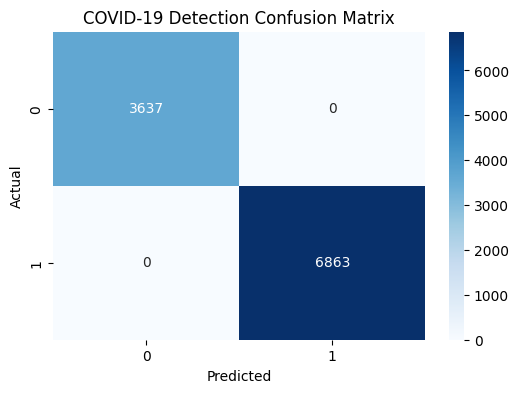

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    confusion_matrix, 
    classification_report
)

# DETAILED EVALUATION
target_class = clf.classes_  # dynamic classes

print("--- Basic Metrics ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.2f}")
# pos_label is needed for binary classification metrics
print(f"Precision: {precision_score(y_test, y_pred, pos_label=1):.2f}")
print(f"Recall:    {recall_score(y_test, y_pred, pos_label=1):.2f}")
print(f"F1-Score:  {f1_score(y_test, y_pred, pos_label=1):.2f}")

print("\n--- Detailed Classification Report ---")
# Provides breakdown for every class
print(classification_report(y_test, y_pred))

print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred, labels=target_class)
print(cm)

# Optional: Visualizing the Confusion Matrix
# This makes it much easier to see where the model is failing
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=target_class, yticklabels=target_class, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('COVID-19 Detection Confusion Matrix')
plt.show()

In [13]:
# stroke data
stroke_df = pd.read_csv('../data/new datasset + classifications/stroke_risk_dataset.csv')

stroke_df.describe()
stroke_df.info()
stroke_df.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Chest Pain                      70000 non-null  int64  
 1   Shortness of Breath             70000 non-null  int64  
 2   Irregular Heartbeat             70000 non-null  int64  
 3   Fatigue & Weakness              70000 non-null  int64  
 4   Dizziness                       70000 non-null  int64  
 5   Swelling (Edema)                70000 non-null  int64  
 6   Pain in Neck/Jaw/Shoulder/Back  70000 non-null  int64  
 7   Excessive Sweating              70000 non-null  int64  
 8   Persistent Cough                70000 non-null  int64  
 9   Nausea/Vomiting                 70000 non-null  int64  
 10  High Blood Pressure             70000 non-null  int64  
 11  Chest Discomfort (Activity)     70000 non-null  int64  
 12  Cold Hands/Feet                 70000 non-n

,Chest Pain,Shortness of Breath,Irregular Heartbeat,Fatigue & Weakness,Dizziness,Swelling (Edema),Pain in Neck/Jaw/Shoulder/Back,Excessive Sweating,Persistent Cough,Nausea/Vomiting,High Blood Pressure,Chest Discomfort (Activity),Cold Hands/Feet,Snoring/Sleep Apnea,Anxiety/Feeling of Doom,Age,Stroke Risk (%),At Risk (Binary)
0,0,1,1,1,0,0,0,1,1,1,0,1,1,0,0,54,58.0,1
1,0,0,1,0,0,1,0,0,0,0,1,0,1,1,0,49,40.5,0
2,1,0,0,1,1,1,0,0,1,0,0,0,0,1,0,62,52.0,1
3,1,0,1,1,0,1,1,1,1,1,1,0,0,0,0,48,60.0,1
4,0,0,1,0,0,1,0,1,0,1,1,0,0,1,1,61,56.5,1


In [15]:
# BLIND SVM on all columns

# Separate Features and Target
X = stroke_df.drop(['Stroke Risk (%)', 'At Risk (Binary)'], axis=1)
y = stroke_df['At Risk (Binary)']

# Define Preprocessing for Numerical and Categorical Features
numeric_features = ['Age']
numeric_transformer = StandardScaler()

# other than numerical all are categorical and boolean
# so going with oe hot encoding
categorical_features = [col for col in X.columns if col not in numeric_features]
categorical_transformer = OneHotEncoder(handle_unknown='ignore', drop = 'first')

# Combine Preprocessing steps using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Create the full Pipeline (Preprocessing + SVM Model)
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='linear')) # Linear kernel for binary classification
])

# Split data and train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
clf.fit(X_train, y_train)

# Evaluate performance
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3637
           1       1.00      1.00      1.00      6863

    accuracy                           1.00     10500
   macro avg       1.00      1.00      1.00     10500
weighted avg       1.00      1.00      1.00     10500



--- Basic Metrics ---
Accuracy:  1.00
Precision: 1.00
Recall:    1.00
F1-Score:  1.00

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3637
           1       1.00      1.00      1.00      6863

    accuracy                           1.00     10500
   macro avg       1.00      1.00      1.00     10500
weighted avg       1.00      1.00      1.00     10500


--- Confusion Matrix ---
[[3637    0]
 [   0 6863]]


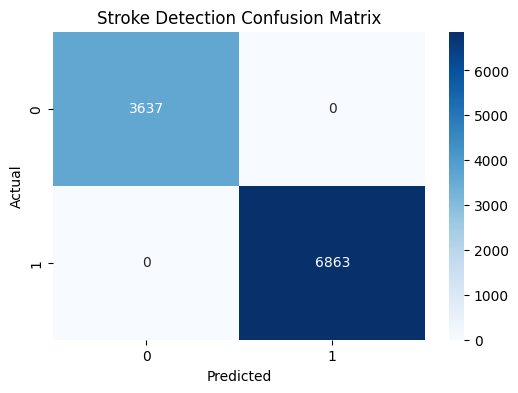

In [17]:
# DETAILED EVALUATION
target_class = clf.classes_  # dynamic email classes

print("--- Basic Metrics ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.2f}")
# pos_label is needed for binary classification metrics
print(f"Precision: {precision_score(y_test, y_pred, pos_label=1):.2f}")
print(f"Recall:    {recall_score(y_test, y_pred, pos_label=1):.2f}")
print(f"F1-Score:  {f1_score(y_test, y_pred, pos_label=1):.2f}")

print("\n--- Detailed Classification Report ---")
# Provides breakdown for every class
print(classification_report(y_test, y_pred))

print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred, labels=target_class)
print(cm)

# Optional: Visualizing the Confusion Matrix
# This makes it much easier to see where the model is failing
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=target_class, yticklabels=target_class, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Stroke Detection Confusion Matrix')
plt.show()

In [19]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# NOW we will test on K=10 fold cross validation because my models are showing 100% result
# Separate Features and Target
X = clean_covid_df.drop(['patient_id', 'covid_result'], axis=1)
y = clean_covid_df['covid_result']

# Define Preprocessing for Numerical and Categorical Features
numeric_features = ['age', 'oxygen_level', 'body_temperature']
numeric_transformer = StandardScaler()

# other than numerical all are categorical and boolean or having 3-4 distinct values
# so going with oe hot encoding
categorical_features = [col for col in X.columns if col not in numeric_features]
categorical_transformer = OneHotEncoder(handle_unknown='ignore', drop = 'first')

# Combine Preprocessing steps using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Create the full Pipeline (Preprocessing + SVM Model)
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='linear')) # Linear kernel for binary classification
])

# CROSS validation
# Define the 10-Fold Stratified Split
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Define the metrics to evaluate
scoring = ['accuracy', 'precision', 'recall', 'f1']

# Run Cross-Validation
results = cross_validate(clf, X, y, cv=skf, scoring=scoring, return_train_score=False)

# Display Detailed Results
print(f"{'Metric':<15} | {'Mean Score':<12} | {'Std Dev'}")
print("-" * 40)
for metric in scoring:
    mean_score = results[f'test_{metric}'].mean()
    std_score = results[f'test_{metric}'].std()
    print(f"{metric.capitalize():<15} | {mean_score:.4f}       | {std_score:.4f}")

Metric          | Mean Score   | Std Dev
----------------------------------------
Accuracy        | 1.0000       | 0.0000
Precision       | 1.0000       | 0.0000
Recall          | 1.0000       | 0.0000
F1              | 1.0000       | 0.0000


In [20]:
# NOW we will test on K=10 fold cross validation on different set of data because my models are showing 100% result
# Separate Features and Target
X = stroke_df.drop(['Stroke Risk (%)', 'At Risk (Binary)'], axis=1)
y = stroke_df['At Risk (Binary)']

# Define Preprocessing for Numerical and Categorical Features
numeric_features = ['Age']
numeric_transformer = StandardScaler()

# other than numerical all are categorical and boolean or having 3-4 distinct values
# so going with oe hot encoding
categorical_features = [col for col in X.columns if col not in numeric_features]
categorical_transformer = OneHotEncoder(handle_unknown='ignore', drop = 'first')

# Combine Preprocessing steps using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Create the full Pipeline (Preprocessing + SVM Model)
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='linear')) # Linear kernel for binary classification
])

# CROSS validation
# Define the 10-Fold Stratified Split
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Define the metrics to evaluate
scoring = ['accuracy', 'precision', 'recall', 'f1']

# Run Cross-Validation
results = cross_validate(clf, X, y, cv=skf, scoring=scoring, return_train_score=False)

# Display Detailed Results
print(f"{'Metric':<15} | {'Mean Score':<12} | {'Std Dev'}")
print("-" * 40)
for metric in scoring:
    mean_score = results[f'test_{metric}'].mean()
    std_score = results[f'test_{metric}'].std()
    print(f"{metric.capitalize():<15} | {mean_score:.4f}       | {std_score:.4f}")

Metric          | Mean Score   | Std Dev
----------------------------------------
Accuracy        | 1.0000       | 0.0000
Precision       | 1.0000       | 0.0000
Recall          | 1.0000       | 0.0000
F1              | 1.0000       | 0.0000
